# Preprocessing

In [1]:
import numpy as np
import pandas as pd


In [2]:
df = pd.read_csv("../data/reddit.csv")
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [3]:
df.shape

(37249, 2)

In [4]:
df.sample()['clean_comment'].values

array(['ahmedabad should renamed karnavati allahabad should renamed prayag brainers when madras can become chennai why can allahabad renamed prayag '],
      dtype=object)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [6]:
df.isnull().sum()

clean_comment    100
category           0
dtype: int64

In [7]:
df[df['clean_comment'].isna()]

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [8]:
df[df['clean_comment'].isna()]['category'].value_counts()

category
0    100
Name: count, dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(350)

In [11]:
df[(df['clean_comment'].str.strip() == '')]

,clean_comment,category
181,,0
375,,0
392,,0
651,,0
1222,,0
...,...,...
35711,,0
35778,,0
35987,,0
36707,,0


In [12]:
df = df[~(df['clean_comment'].str.strip()== '')]

In [13]:
# convert 'clean_comment' column to lowercase
df['clean_comment'] = df['clean_comment'].str.lower()

# verify the convertation by displaying the first few rows
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [14]:
df[df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' '))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [15]:
# remove trailing and leading whitespaces from the column 'clean_comment' 
df['clean_comment'] = df['clean_comment'].str.strip() 

# verify the transformation by checking for any remaining trailing whitespaces
df[df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' '))].sum()

clean_comment    0
category         0
dtype: object

In [16]:
# identify comments containing URLs
url_pattern = r'https?://[^\s]+'
comments_with_urls = df[df['clean_comment'].str.contains(url_pattern,regex=True)]

# display comments with URLs
comments_with_urls.head()

,clean_comment,category


In [17]:
# identify commnets with new line characters 
comments_with_newline = df[df['clean_comment'].str.contains('\n')]

# display comments with new line
comments_with_newline.head()

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1


In [18]:
# remove new line characters from the clean_comment column 
df['clean_comment'] = df['clean_comment'].str.replace('\n', ' ', regex = True)

#verify transformation by checking for any remaining new lines 
comments_with_newline = df[df['clean_comment'].str.contains('\n')]
comments_with_newline


,clean_comment,category


# EDA

<Axes: xlabel='category', ylabel='count'>

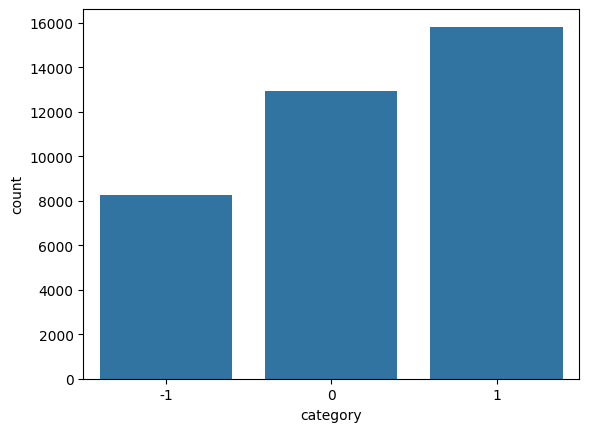

In [19]:
import seaborn as sns 
import matplotlib.pyplot as plt 
#distribution of class 

sns.countplot(data = df, x = 'category')

In [20]:
# frequency distribution of sentiments 

df['category'].value_counts(normalize=True).mul(1).round(8)

category
 1    0.427514
 0    0.348952
-1    0.223534
Name: proportion, dtype: float64

In [21]:
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))

In [22]:
df.sample(10)

,clean_comment,category,word_count
28242,what people calling for all out war need reali...,1,41
1753,feel have all gone over board this mass hyster...,-1,25
15609,seeing stuff like this makes realize how lucky...,1,62
16782,allowed the moderator here,0,4
36688,but this good for them they will busy again fo...,1,30
33478,the statement from the farmer priyanka that ch...,1,35
16112,this the time for aap lead the charge congress...,-1,36
31877,better than worshipping cows and killing peopl...,1,8
9374,sad state affairs when not wanting president w...,-1,20
28238,meanwhile pakistan can even get back reconnais...,1,10


In [23]:
df['word_count'].describe()

count    37028.000000
mean        29.499919
std         56.654363
min          1.000000
25%          6.000000
50%         13.000000
75%         30.000000
max       1307.000000
Name: word_count, dtype: float64

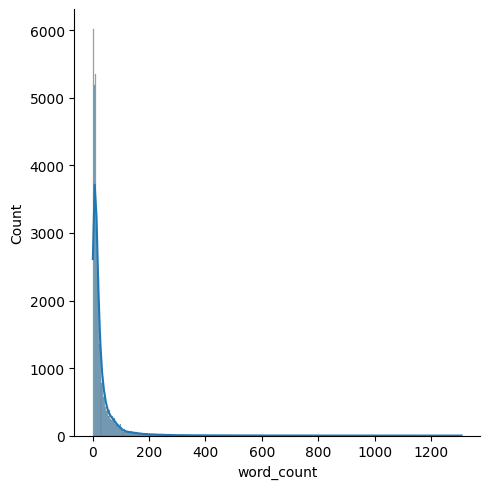

In [24]:
sns.displot(df['word_count'],kde=True)

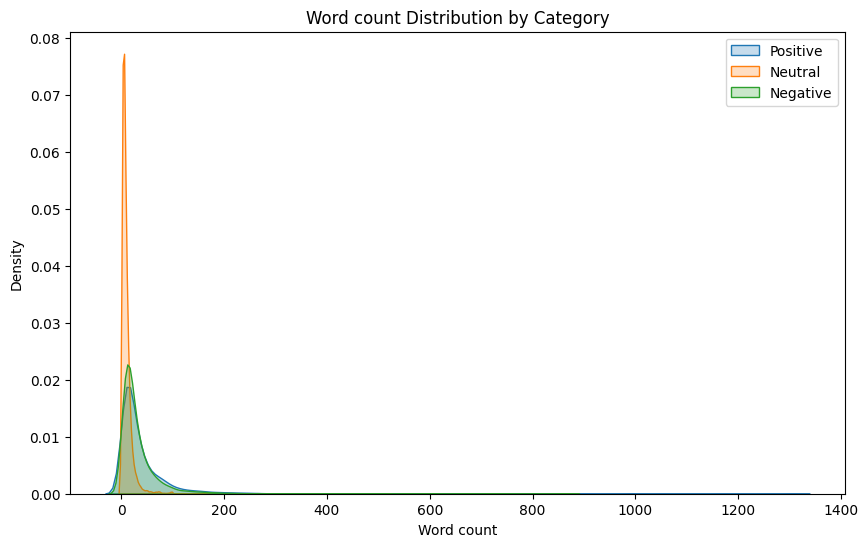

In [25]:
# create the figure for and axes

plt.figure(figsize=(10,6))

sns.kdeplot(df[df['category'] == 1]['word_count'], label='Positive',fill=True)
sns.kdeplot(df[df['category'] == 0]['word_count'], label='Neutral',fill=True)
sns.kdeplot(df[df['category'] == -1]['word_count'], label='Negative',fill=True)

plt.title("Word count Distribution by Category")
plt.xlabel('Word count')
plt.ylabel('Density')
plt.legend()
plt.show()

**Postive comments (Category 1)**: These  tend to have a wider spread in word count, indicating that longer comments are more common in positive sentimenents.
**Neutral comments (Category 2)**: The distribution shows a relativly lower frequency and is more concentrated around shorter comments compared to positive or negative ones.
**Negative comments (Category -1)**: These comments have a distribution somewhat similiar to positive comments but with a smaller proportion of longer comments.

<Axes: ylabel='word_count'>

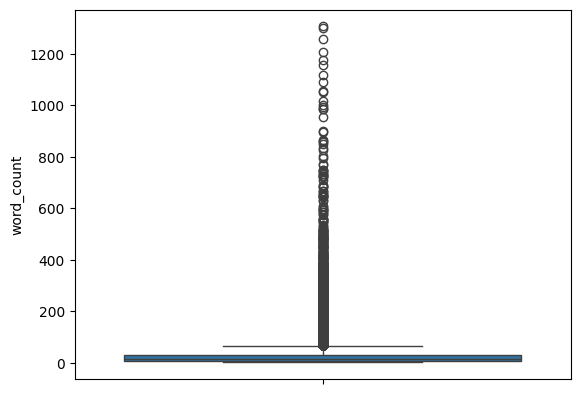

In [26]:
sns.boxplot(df['word_count'])

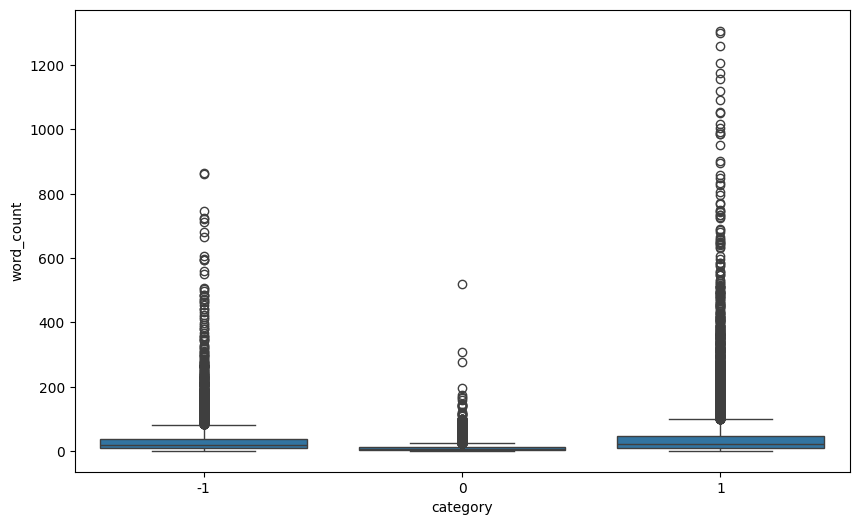

In [27]:
# create boxplot for the column 'word_count' categorized by 'category'
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='category',y='word_count')
sns.title ='Boxplot of Word Count by Category'
sns.xlabel = 'Category'
sns.ylabel = 'Word Count'
plt.show()

**Positive comments (Category 1)**: The median is relatively high, and there are several outlines with longer comments, indicating that positive comments tend to be more verbose.
**Neutral comments (Category 0)**: The median count is the lowest, with tighter IQR, suggesting ther neutral comments are generally shorter.
**Negative comments (Category -1)**: The distribution is kinda similiar to category 1, but have a slightly lower median and fewer extreme outilers.

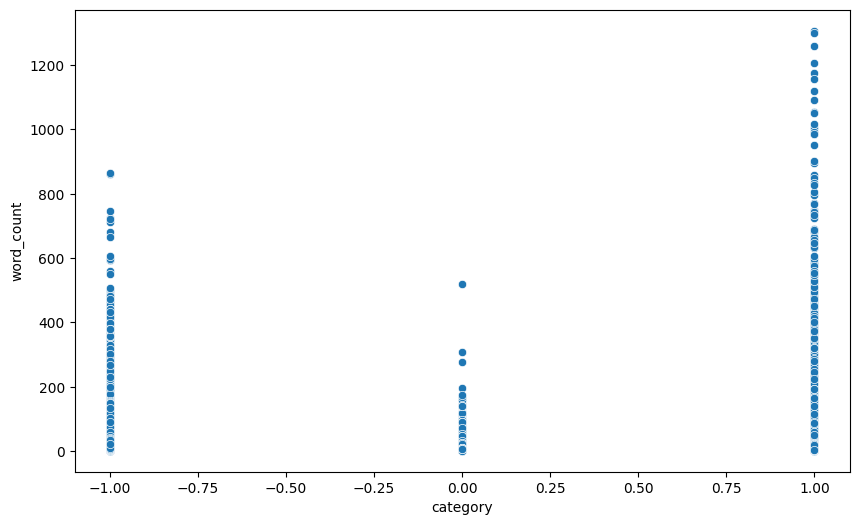

In [28]:
# create scatterplot between 'category' and 'word_count'
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x = 'category', y = 'word_count')
plt.title ='Scatterplot of Word Count by Category'
plt.xlabel ='Category'
plt.ylable = 'Word count'
plt.show()

<Axes: xlabel='category', ylabel='word_count'>

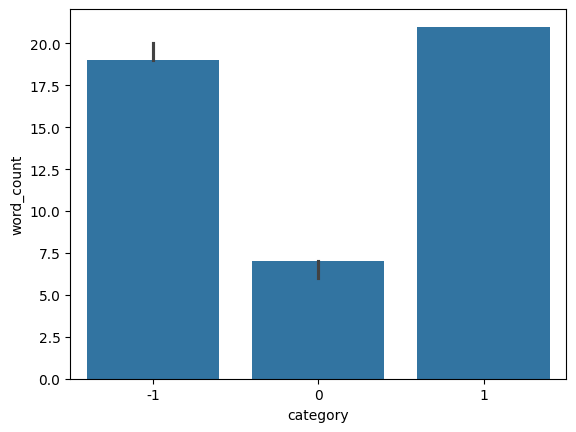

In [29]:
# m
sns.barplot(df, x='category', y='word_count',estimator='median')

In [30]:
!зшз штыефpip install nltk 

zsh:1: command not found: зшз


In [31]:
# Download nltk stopwords if not already downloaded 
import nltk 

try:
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords")
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words("english"))


stop_words = set(stopwords.words('english'))

#create a new column 'num_stop_words' by counting the number of stop_words in each comment
df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

In [32]:
df.sample(5)

,clean_comment,category,word_count,num_stop_words
23029,350,0,1,0
20626,while completely agree with what pisses off ev...,1,42,16
13727,not worry fellas come april 2019 modi and shah...,0,19,5
30691,just arrested should beaten black and blue unt...,-1,11,5
14408,when they hugged the end smiled widely and che...,1,11,4


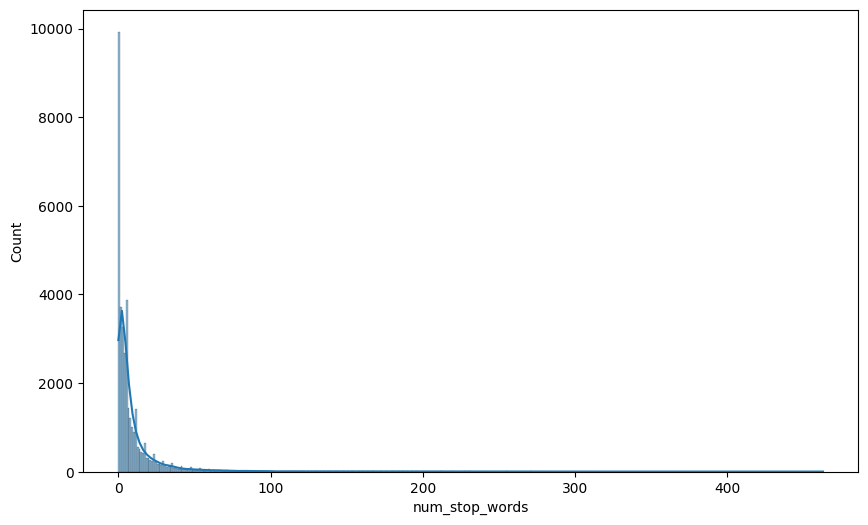

In [33]:
# create a distribution plot for the (num_stop_words) column 
plt.figure(figsize=(10,6))
sns.histplot(df['num_stop_words'],kde=True)
plt.title = 'Distribution of Stop Word Count in comments'
plt.xlabel = 'Quantity of stop numbers'
plt.ylabel = 'Frequency'

plt.show()

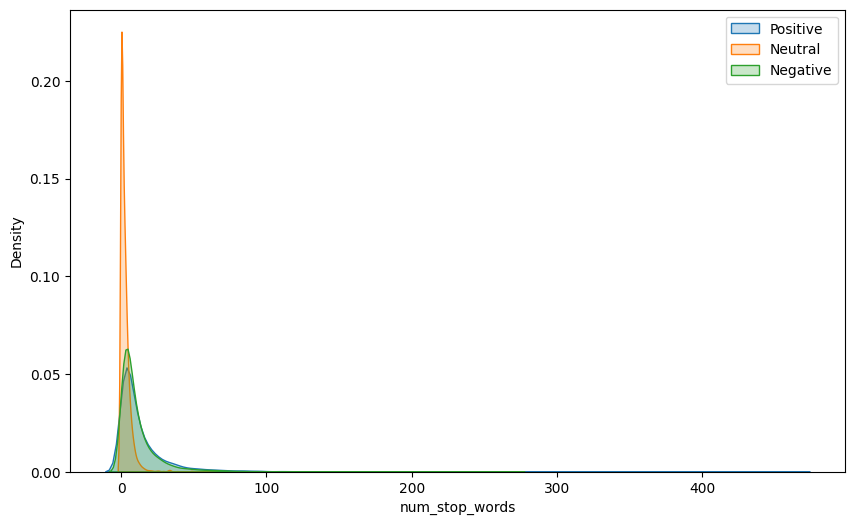

In [34]:
# create the figure and axes
plt.figure(figsize=(10,6))

sns.kdeplot(df[df['category'] == 1]['num_stop_words'],label='Positive',fill=True)
sns.kdeplot(df[df['category'] == 0]['num_stop_words'],label='Neutral',fill=True)
sns.kdeplot(df[df['category'] == -1]['num_stop_words'],label='Negative',fill=True)

plt.title = 'Num stop words Distribution in category'
plt.xlabel = 'Stop Words Count'
plt.ylable = 'Density'

plt.legend()
plt.show()

<Axes: xlabel='category', ylabel='num_stop_words'>

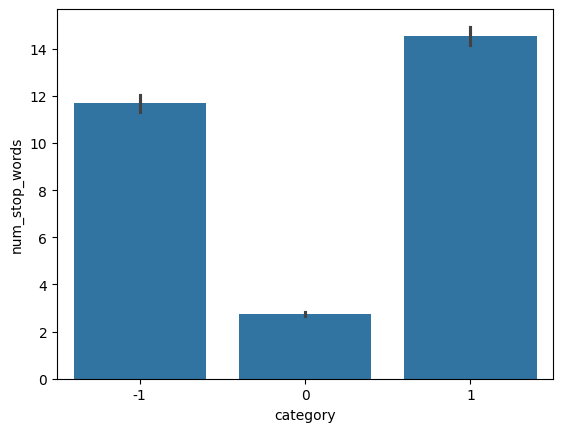

In [35]:
# median for num_stop_words column 

sns.barplot(df,x='category',y='num_stop_words')

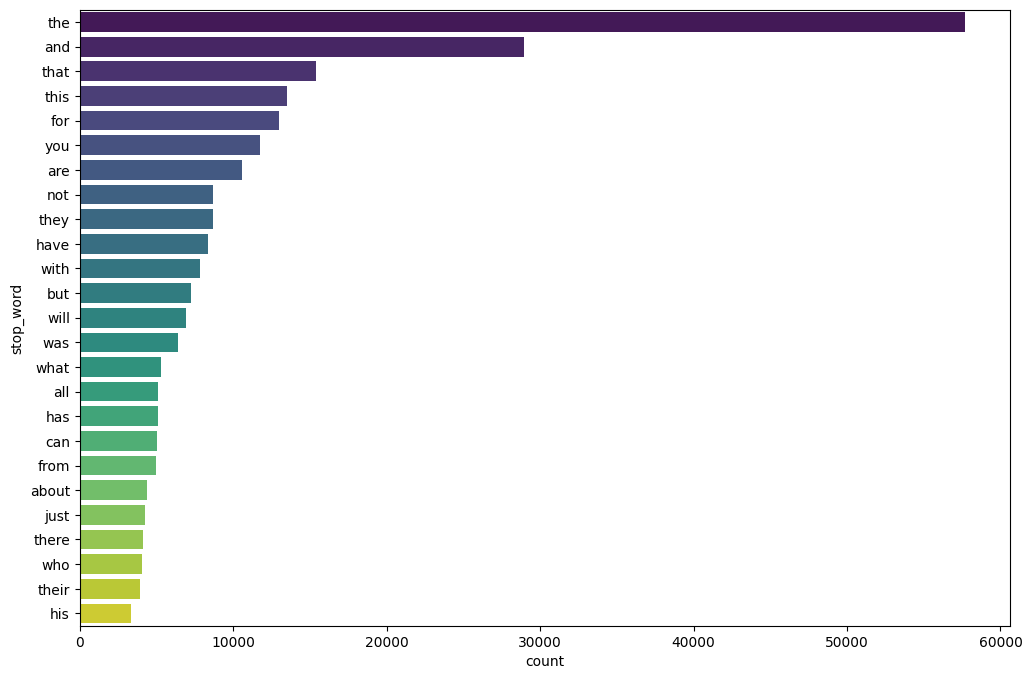

In [36]:
# create a frequency distribution of stop words in the 'clean_comment' column
from collections import Counter 

# extract all stop words from the comments using the previously defined 'common_stopwords'
all_stop_words = [word for comment in df['clean_comment'] for word in comment.split() if word in stop_words]

# count the most common stop words
most_common_stop_words = Counter(all_stop_words).most_common(25)

# convert the most common stop words into DataFrame for plotting
top_25_df = pd.DataFrame(most_common_stop_words,columns=['stop_word','count'])

#create barplot for the top 25 most common stop_words
plt.figure(figsize=(12,8))
sns.barplot(data=top_25_df, x ='count',y='stop_word',hue='stop_word',palette='viridis',legend=False)
plt.title = 'Top 25 most common Stop Words'
plt.xlabel ='Count'
plt.ylabel = 'Stop word'
plt.show()

In [37]:
df['num_chars'] = df['clean_comment'].apply(len)

df.head()

,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,1,39,13,259
1,buddhism has very much lot compatible with chr...,1,196,59,1268
2,seriously don say thing first all they won get...,-1,86,40,459
3,what you have learned yours and only yours wha...,0,29,15,167
4,for your own benefit you may want read living ...,1,112,45,690


In [38]:
df['num_chars'].describe()

count    37028.000000
mean       180.813303
std        358.823615
min          1.000000
25%         37.000000
50%         79.000000
75%        183.000000
max       8664.000000
Name: num_chars, dtype: float64

In [39]:
from collections import Counter
all_text = ''.join(df['clean_comment'])

# convert into DataFrame
char_frequency = Counter(all_text)

char_frequency_df = pd.DataFrame(char_frequency.items(),columns=['character','frequency']).sort_values (by='frequency',ascending=True)

In [40]:
char_frequency_df['character'].values

array(['∀', '￼', 'ಳ', ..., 't', 'e', ' '], shape=(1378,), dtype=object)

In [41]:
char_frequency_df.tail(50)

,character,frequency
66,ि,232
456,ė,280
72,्,285
71,ो,305
67,ं,325
98,@,366
69,ी,394
60,\,476
68,े,519
57,”,665


In [42]:
# create a new column 'char_punctuation_chars' to count punctuation characters in each comment
df['num_punctuation_chars'] = df['clean_comment'].str.count(r'[^\w\s]')

df.sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
11586,because police allow this good buddies read th...,1,70,28,394,0
22187,kaash mai congress mla hota transaltion fuck w...,-1,11,1,66,0
6931,traitor rahul gandhi should hanged and shot sa...,0,23,3,140,0
17040,they look cute together here the source,1,7,3,39,0
13725,least the washington post was kind enough refe...,1,9,2,55,0


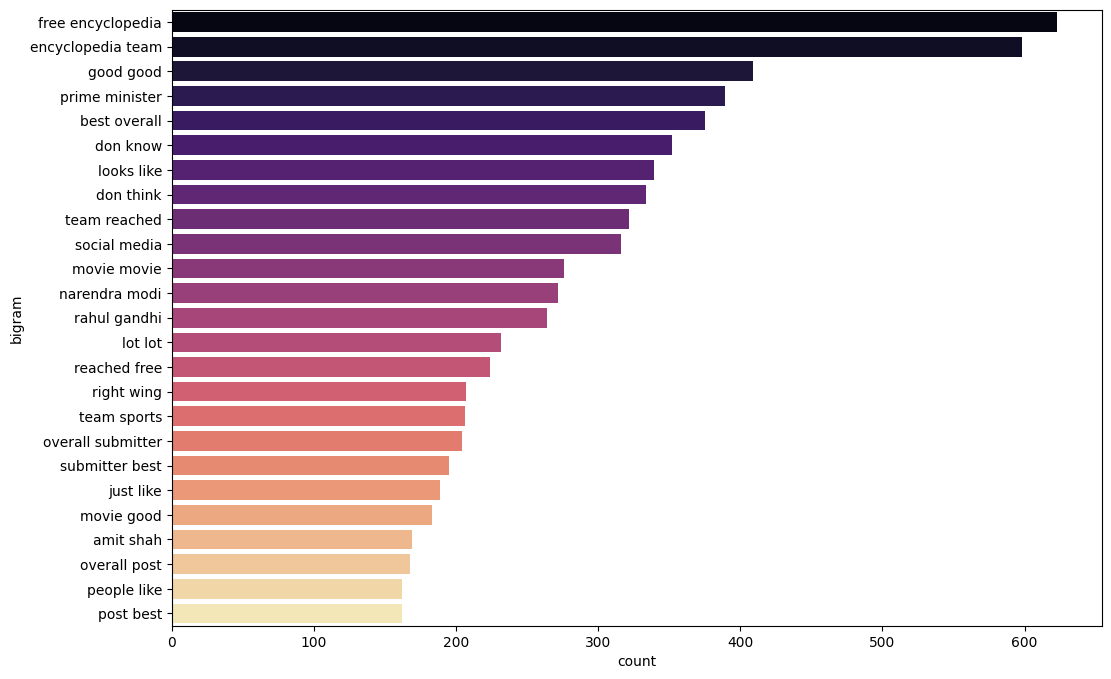

In [43]:
from sklearn.feature_extraction.text import CountVectorizer 

# create a function to extract the top 25 bigrams
def get_top_ngrams(corpus,n=None):
    vec = CountVectorizer(ngram_range=(2,2),stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0,idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x :x [1],reverse=True)
    return words_freq[:n]

# Get the top 25 bigrams 
top_25_bigrams = get_top_ngrams(df['clean_comment'], 25)

# convert into DataFrame for plotting 
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns=['bigram','count'])

# Plot the countplot for the top 25 bigrams 
plt.figure(figsize=(12,8))
sns.barplot(data=top_25_bigrams_df,x='count',y='bigram',hue='bigram',palette='magma',legend=False)
plt.title = 'Top 25 Most Common Bigrams'
plt.xlabel = 'Count'
plt.ylabel = 'Bigram'

plt.show()

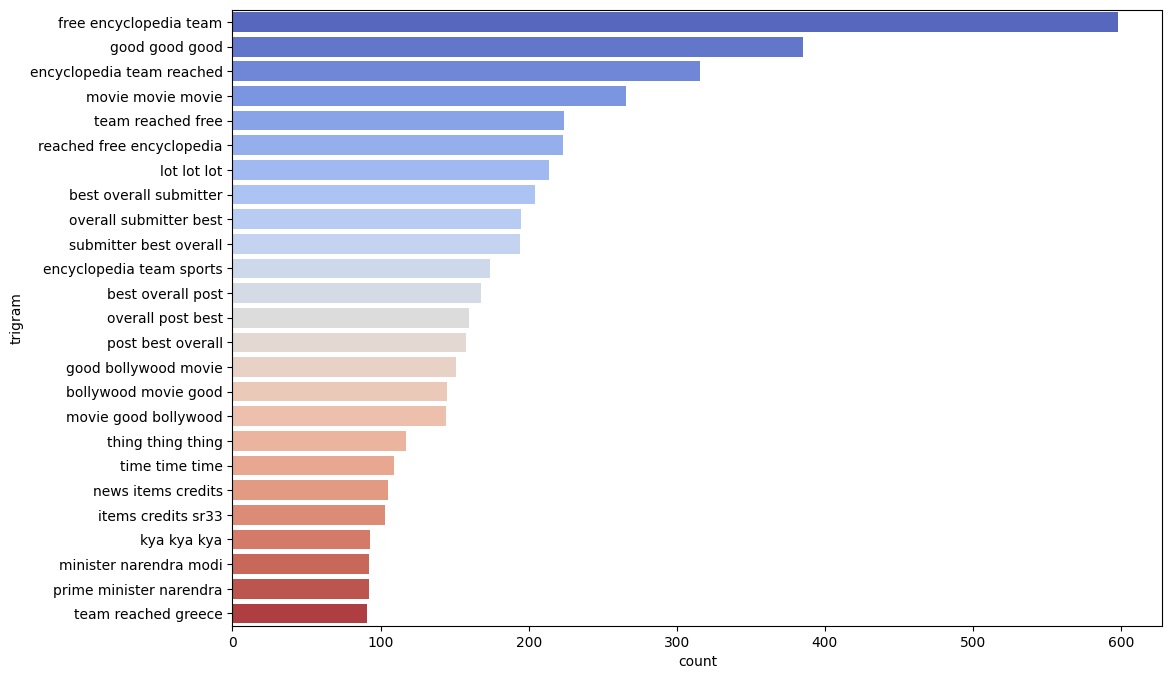

In [44]:
def get_top_trigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3,3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

    
# get top 25 trigrams 
top_25_trigrams = get_top_trigrams(df['clean_comment'], 25)

# convert to DataFrame

top_25_trigrams_df = pd.DataFrame(top_25_trigrams, columns = ['trigram','count'])

plt.figure(figsize=(12,8))
sns.barplot(data=top_25_trigrams_df, x = 'count', y = 'trigram', hue='trigram', palette='coolwarm',legend=False)
plt.title = 'Top 25 most common trigrams'
plt.xalbel = 'Count'
plt.ylabel = 'Trigram'

plt.show()

In [45]:
# removing non-English characters from the 'clean_comment column'
# Keeping only standart English letters, digits, and common punctation
import re 

df['clean_comment'] = df['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]', '', str(x)))

In [46]:
all_text = ''.join(df['clean_comment'])

char_frequency = Counter(all_text)

char_frequency_df = pd.DataFrame(char_frequency.items(),columns=['characters','frequency']).sort_values(by='frequency', ascending=False)

char_frequency_df

,characters,frequency
6,,1055333
12,e,667025
13,t,491655
1,a,481442
3,i,401612
9,n,388677
7,o,380205
17,s,355521
8,r,331588
10,h,296971


In [47]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon have never tried explain them th...,1,39,13,259,0
1,buddhism has very much lot compatible with chr...,1,196,59,1268,0
2,seriously don say thing first all they won get...,-1,86,40,459,0
3,what you have learned yours and only yours wha...,0,29,15,167,0
4,for your own benefit you may want read living ...,1,112,45,690,0


In [48]:
from nltk.corpus import stopwords

# defining stop words but keeping essential ones for sentiment analysis
stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}

# remove stop words from 'clean_comment' column, retaining essential ones 
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])  
)

In [49]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


In [50]:
from nltk.stem import WordNetLemmatizer 


nltk.download('wordnet')

# define the lemmatizer 

lemmatizer = WordNetLemmatizer()

# apply lemmatization to the 'clean_comment_no_stopwords' column 
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

df.head()

[nltk_data] Downloading package wordnet to /home/grayfog/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


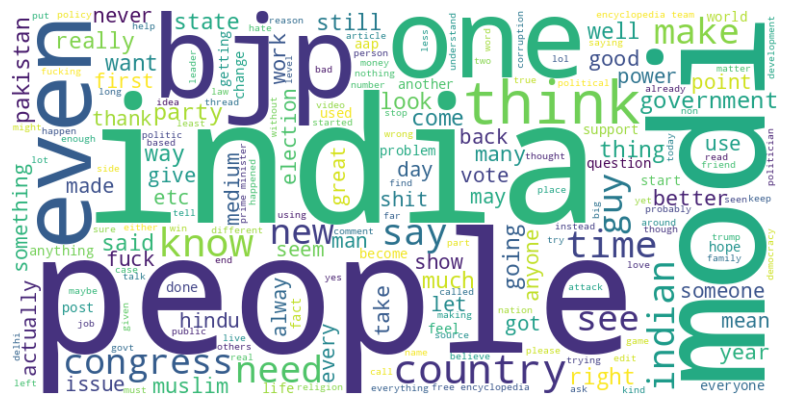

In [51]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width = 800, height = 400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud,interpolation = 'bilinear')
    plt.axis('off')
    plt.show()

plot_word_cloud(df['clean_comment'])

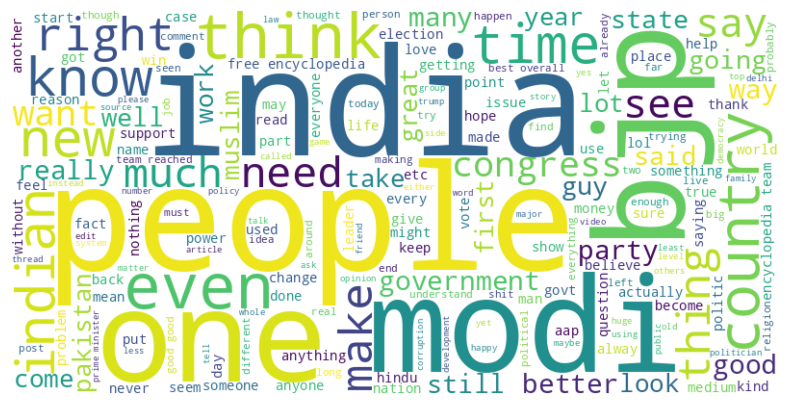

In [52]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width = 800, height = 400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud,interpolation='bilinear')
    plt.axis('off')
    plt.show

plot_word_cloud(df[df['category'] == 1]['clean_comment'])

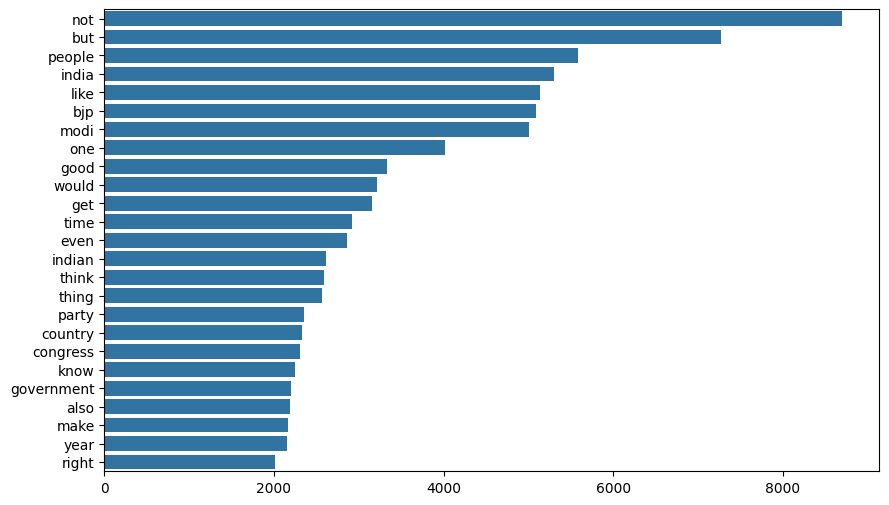

In [53]:
def plot_top_n_words(df,n=20):
    words = ' '.join(df['clean_comment']).split()

    # get top N common words
    counter = Counter(words)
    most_common_words = counter.most_common(n)

    # split words and counts for plotting
    words, counts = zip(*most_common_words)

    # plot the top N words
    plt.figure(figsize=(10,6))
    sns.barplot(x=list(counts),y=list(words))
    plt.title = f'Top {n} Most Frequent Words'
    plt.xlabel = 'Frequency'
    plt.ylabel = 'Count'
    plt.show()

plot_top_n_words(df,n=25)

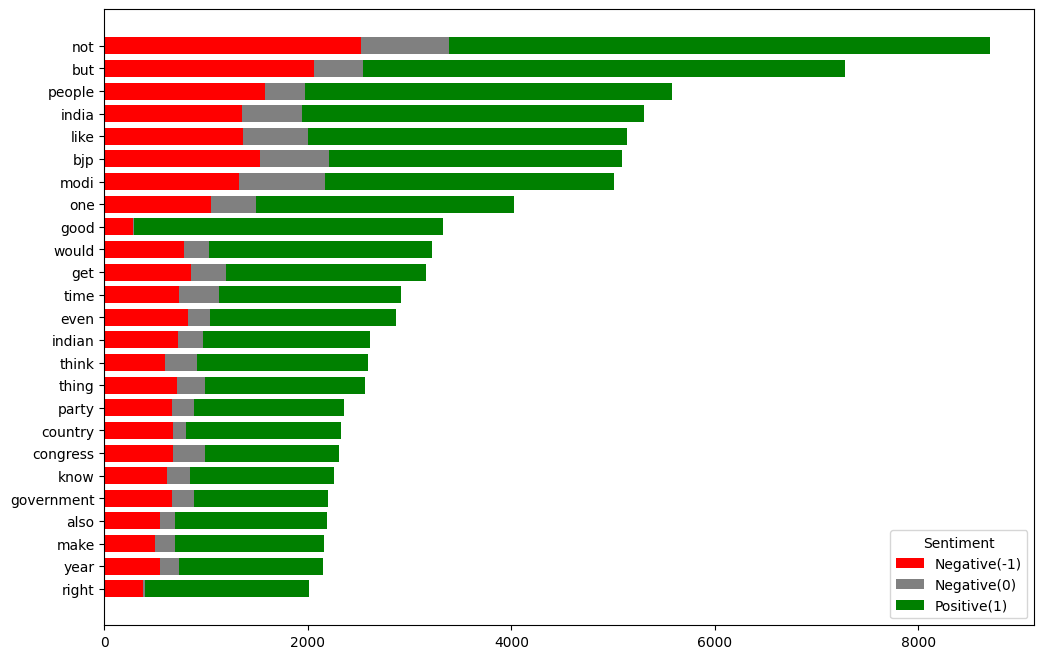

In [54]:
def plot_top_n_words_by_category(df,n=20, start = 0):
    word_category_counts = {}

    for idx, row in df.iterrows():
        words = row['clean_comment'].split()
        category = row['category']
        for word in words:
            if word not in word_category_counts:
                word_category_counts[word] = {-1:0, 0:0, 1:0} # init hashmap 

            word_category_counts[word][category] += 1
    
    # get total counts across all categories 
    total_word_counts = {word: sum(counts.values()) for word, counts in word_category_counts.items()}

    # get top N most frequent words across all categories 
    most_common_words = sorted(total_word_counts.items(), key = lambda x: x[1], reverse=True)[start:start+n]
    top_words = [word for word,_ in most_common_words]

    # prepare data for plotting 
    word_labels = top_words 
    negative_counts = [word_category_counts[word][-1] for word in top_words]
    neutral_counts = [word_category_counts[word][0] for word in top_words]
    positive_counts = [word_category_counts[word][1] for word in top_words]

    # plot the stack bar 
    plt.figure(figsize=(12,8))
    bar_width = 0.75

    # plot negative, neutral, and positive counts in stacked manner 
    plt.barh(word_labels, negative_counts, color='red', label='Negative(-1)', height=bar_width)
    plt.barh(word_labels, neutral_counts, left=negative_counts, color='gray', label='Negative(0)', height=bar_width)
    plt.barh(word_labels, positive_counts, left=[i+j for i,j in zip(negative_counts, neutral_counts)],color ='green', label = 'Positive(1)', height=bar_width)

    plt.xlabel= 'Frequency'
    plt.ylabel = 'Words'
    plt.title = f'Top  {n} Most Common Words by Categories'
    plt.legend(title='Sentiment',loc='lower right')
    plt.gca().invert_yaxis()
    plt.show()

plot_top_n_words_by_category(df,25)